# Project 5B: Flow Matching from Scratch!

## Setup environment

In [4]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [10]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.gelu(self.bn(self.conv(x)))
        # ===== end of code ====
        


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.gelu(self.bn(self.conv(x)))
        # ===== end of code ====


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv_transpose = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.gelu(self.bn(self.conv_transpose(x)))
        # ===== end of code ====


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.avgpool = nn.AvgPool2d(kernel_size=7)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.gelu(self.avgpool(x))
        # ===== end of code ====


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        # ConvTranspose2d to upscale from 1x1 to 7x7
        self.conv_transpose = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=1, padding=0)
        self.bn = nn.BatchNorm2d(in_channels)
        self.gelu = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.gelu(self.bn(self.conv_transpose(x)))
        # ===== end of code ====


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        # Composed operations: two Conv layers to make network deeper without changing dimensions
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.conv2(x)
        return x
        # ===== end of code ====


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        # Composed operations: Conv followed by DownConv
        self.down_conv = DownConv(in_channels, out_channels)
        self.convblock = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.down_conv(x)
        x = self.convblock(x)
        return x
        # ===== end of code ====


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        # Composed operations: ConvBlock to reduce channels, then UpConv to upsample
        self.upconv = UpConv(in_channels, out_channels)
        self.convblock = ConvBlock(out_channels, out_channels)
        
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.upconv(x)
        x = self.convblock(x)
        
        return x
        # ===== end of code ====

## Implementing Unconditional UNet

In [11]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
         # ===== your code here! ====
        D = num_hiddens
        
        # Left path
        self.convblock1 = ConvBlock(in_channels, D)  # 28x28 -> 28x28, channels: in -> D
        self.downblock1 = DownBlock(D, D)       # 28x28 -> 14x14, channels: D -> D
        self.downblock2 = DownBlock(D, 2 * D)    # 14x14 -> 7x7, channels: D -> 2D
        
        # Middle to Final path
        self.flatten = Flatten()                 # 7x7 -> 1x1, 2D -> 2D
        self.upblock1 = UpBlock(4*D, D)       # 7x7 -> 14x14, channels: 4D -> D 
        self.upblock2 = UpBlock(2*D, D)           # 14x14 -> 28x28, channels: 2D -> D
        self.unflatten = Unflatten(2 * D)      # 1x1 -> 7x7, 2D -> 2D      
        self.convblock2 = ConvBlock(2 * D, D)   # 28x28 -> 28x28, channels: 2D -> D
        
        # Output
        self.conv_final = nn.Conv2d(D, in_channels, kernel_size=1, stride=1, padding=0)# 28x28 -> 28x28, channels: 2D -> in_channels
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        
        #left path
        b1 = self.convblock1(x)# (D, 28, 28)
        b2 = self.downblock1(b1)   # (D, 14, 14)
        b3 = self.downblock2(b2) # (2D, 7, 7)
        b4 = self.flatten(b3)    # (2D, 1, 1)
        
        #middle to final path
        b5 = self.unflatten(b4)# (2D, 7, 7)
        b6 = torch.cat([b3, b5], dim=1) # (4D, 7, 7)
        b7 = self.upblock1(b6)# (D, 14, 14)
        b8 = torch.cat([b2, b7], dim=1)     # (2D, 14, 14)
        b9 = self.upblock2(b8) #(D, 28, 28) 
        b10 = torch.cat([b1, b9], dim=1)  # (2D, 28, 28)
        b11 = self.convblock2(b10)  # (D, 28, 28)
        return self.conv_final(b11) #(in_channels, 28, 28)
    # ===== end of code ====

# Part 1.2: Using the UNet to Train a Denoiser

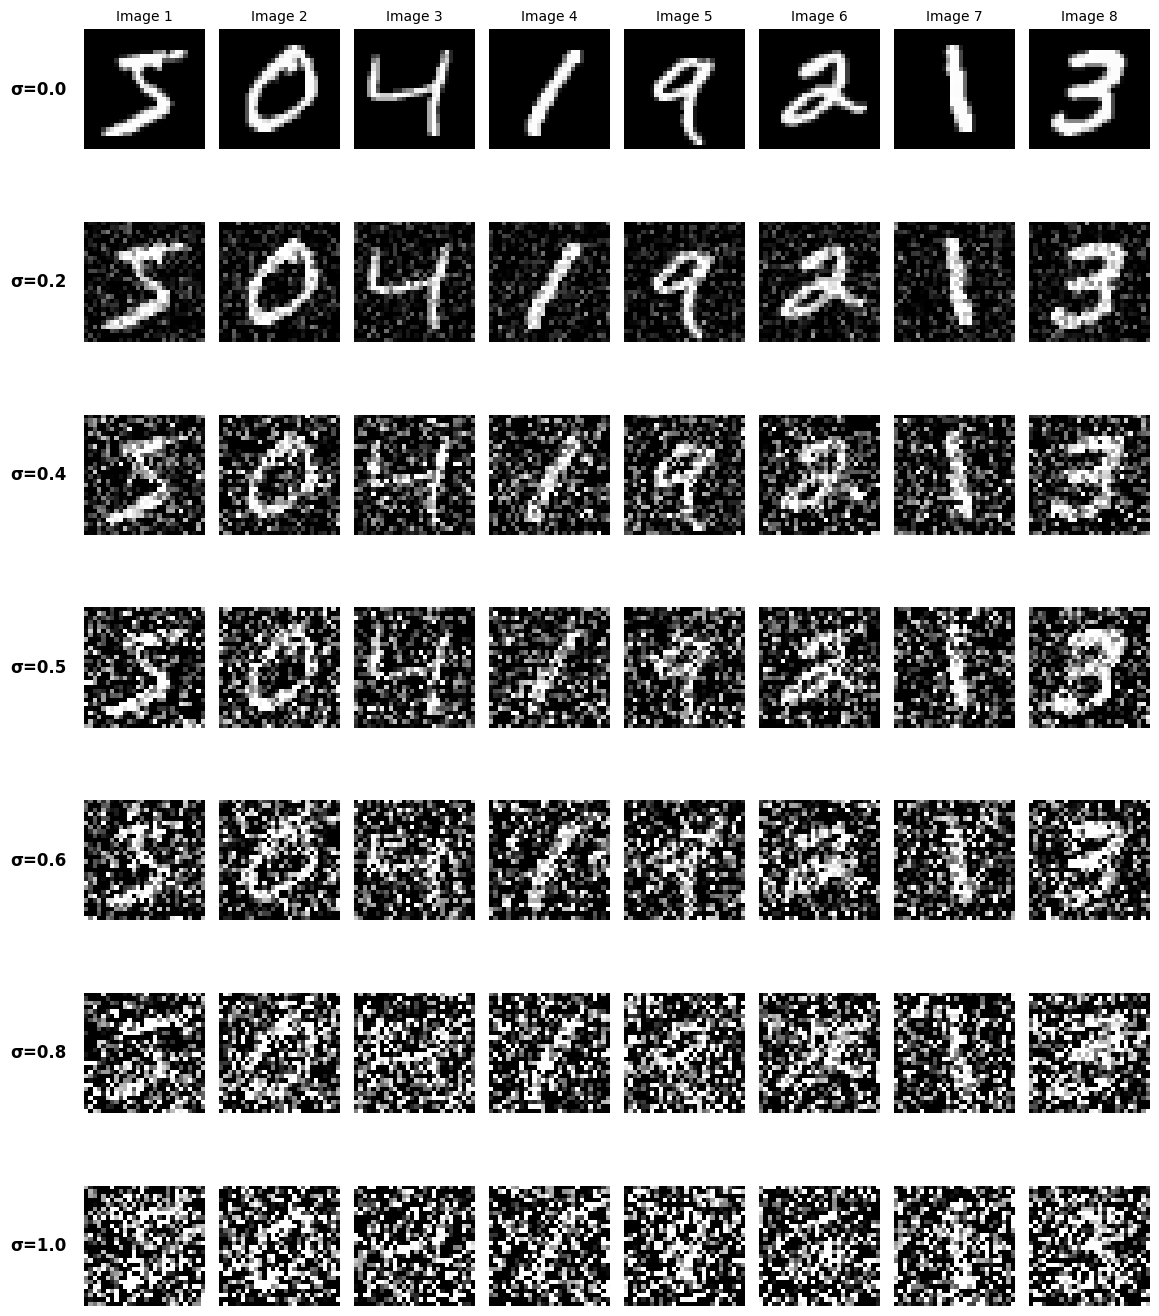

In [14]:
# Visualize images at different noisy level
# ===== your code here! ====
dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())


sample_images = []
for i in range(8):  # sample 8 img
    img, _ = dataset[i]
    sample_images.append(img)

sample_images = torch.stack(sample_images)  #(8, 1, 28, 28)

# noise
sigmas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(len(sigmas), 8, figsize=(12, 2*len(sigmas)))

for noise_level_idx, sigma in enumerate(sigmas):
    for img_idx in range(8):
        # Add noise: x_noisy = x + sigma * noise, where noise ~ N(0, 1)
        noisy_img = sample_images[img_idx] + sigma * torch.randn_like(sample_images[img_idx])
        # Clamp to valid range [0, 1]
        noisy_img = torch.clamp(noisy_img, 0, 1)
        
        axes[noise_level_idx, img_idx].imshow(noisy_img.squeeze(), cmap='gray')
        axes[noise_level_idx, img_idx].axis('off')
    
    # Label each row with its noise level - use text annotation instead of ylabel
    axes[noise_level_idx, 0].text(-0.15, 0.5, f'σ={sigma}', 
                                   transform=axes[noise_level_idx, 0].transAxes,
                                   rotation=0, va='center', ha='right', fontsize=12, fontweight='bold')

# Add column labels
for img_idx in range(8):
    axes[0, img_idx].set_title(f'Image {img_idx+1}', fontsize=10)

plt.tight_layout()
plt.subplots_adjust(left=0.1)  # Add more space on left for row labels
plt.show()
# ===== end of code ====

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [15]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 64
learning_rate = 1e-3
noise_level = 0.5  # sigma value for Gaussian noise
hidden_dim = 64  # num_hiddens for UNet
num_epochs = 10
# ===== end of code ====

In [16]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [17]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()  # Mean Squared Error loss for denoising
# ===== end of code ====

In [18]:
# The training loops
train_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        
        # Add noise to images: x_noisy = x + noise_level * noise, where noise ~ N(0, 1)
        noise = torch.randn_like(images) * noise_level
        noisy_images = images + noise
        noisy_images = torch.clamp(noisy_images, 0, 1)  # Clamp to valid range [0, 1]
        
        # Forward pass: model predicts denoised image
        outputs = model(noisy_images)
        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

100%|██████████| 938/938 [00:33<00:00, 28.33it/s]


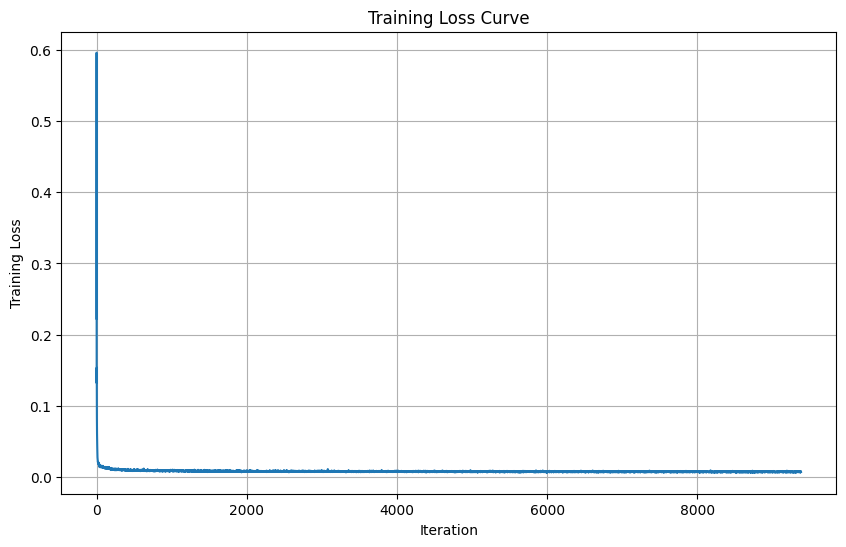

In [19]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()
# ===== end of code ====

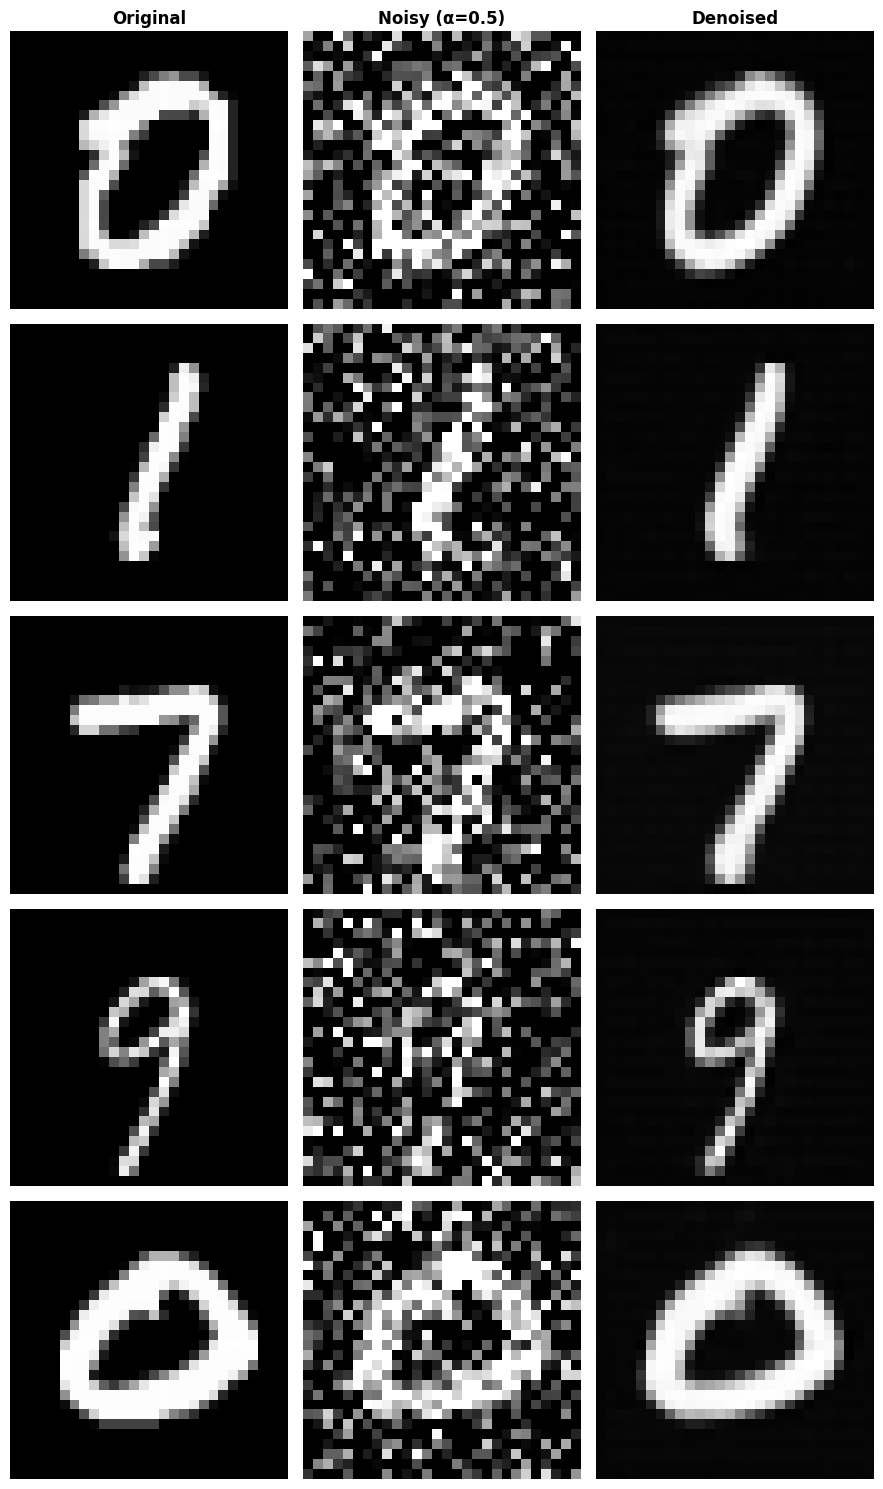

In [20]:
#Visualize denoised images at alpha = 0.5
# ===== your code here! ====
model.eval()  # Set model to evaluation mode
num_samples = 5
alpha = 0.5  # noise level

# Get random samples from test set
indices = torch.randint(0, len(test_dataset), (num_samples,))
sample_images = []
for idx in indices:
    img, _ = test_dataset[idx]
    sample_images.append(img)

sample_images = torch.stack(sample_images).to(device)  # Shape: (5, 1, 28, 28)

# Create noisy images
noise = torch.randn_like(sample_images) * alpha
noisy_images = sample_images + noise
noisy_images = torch.clamp(noisy_images, 0, 1)

# Get denoised images from model
with torch.no_grad():
    denoised_images = model(noisy_images)

# Move to CPU and convert to numpy for plotting
sample_images = sample_images.cpu()
noisy_images = noisy_images.cpu()
denoised_images = denoised_images.cpu()

# Create visualization: 5 rows x 3 columns
fig, axes = plt.subplots(num_samples, 3, figsize=(9, 15))

for i in range(num_samples):
    # Column 1: Original clean image
    axes[i, 0].imshow(sample_images[i].squeeze(), cmap='gray')
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title('Original', fontsize=12, fontweight='bold')
    
    # Column 2: Noisy image
    axes[i, 1].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[i, 1].axis('off')
    if i == 0:
        axes[i, 1].set_title('Noisy (α=0.5)', fontsize=12, fontweight='bold')
    
    # Column 3: Denoised image
    axes[i, 2].imshow(denoised_images[i].squeeze(), cmap='gray')
    axes[i, 2].axis('off')
    if i == 0:
        axes[i, 2].set_title('Denoised', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
# ===== end of code ====


## Part 1.2.2: Out-of-Distribution Testing

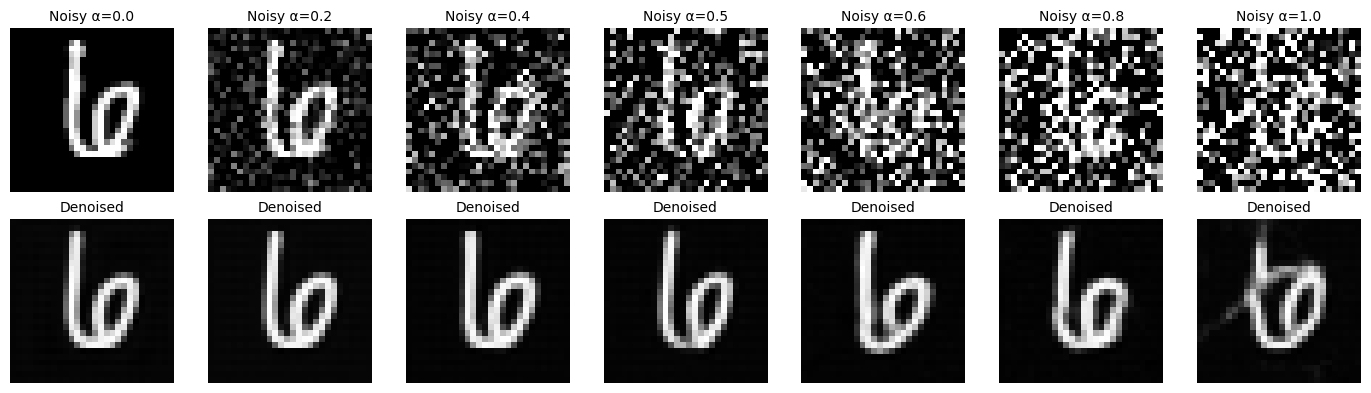

In [21]:
# Visualize OOD testing
# ===== your code here! ====
model.eval()  # Set model to evaluation mode

# Get one random image from test set
idx = torch.randint(0, len(test_dataset), (1,)).item()
original_img, _ = test_dataset[idx]
original_img = original_img.unsqueeze(0).to(device)  # Add batch dimension: (1, 1, 28, 28)

# Different noise levels (alpha values)
alphas = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

# Create noisy images at different alpha levels
noisy_images = []
for alpha in alphas:
    noise = torch.randn_like(original_img) * alpha
    noisy_img = original_img + noise
    noisy_img = torch.clamp(noisy_img, 0, 1)
    noisy_images.append(noisy_img)

noisy_images = torch.cat(noisy_images, dim=0)  # Stack: (7, 1, 28, 28)

# Get denoised images from model
with torch.no_grad():
    denoised_images = model(noisy_images)

# Move to CPU for plotting
original_img = original_img.cpu()
noisy_images = noisy_images.cpu()
denoised_images = denoised_images.cpu()

# Create 2x7 grid: first row = noisy, second row = denoised
fig, axes = plt.subplots(2, len(alphas), figsize=(14, 4))

# First row: Noisy images
for i, alpha in enumerate(alphas):
    axes[0, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Noisy α={alpha}', fontsize=10)

# Second row: Denoised images
for i, alpha in enumerate(alphas):
    axes[1, i].imshow(denoised_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Denoised', fontsize=10)

plt.tight_layout()
plt.show()
# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

100%|██████████| 938/938 [00:26<00:00, 35.05it/s]



=== Results after Epoch 1 ===


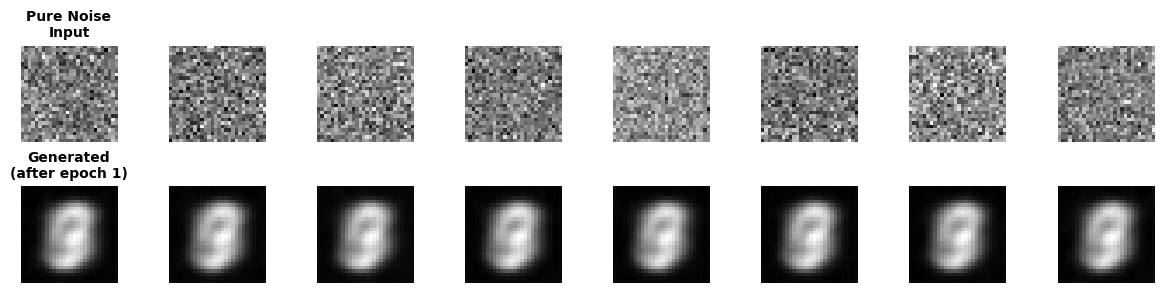


=== Results after Epoch 5 ===


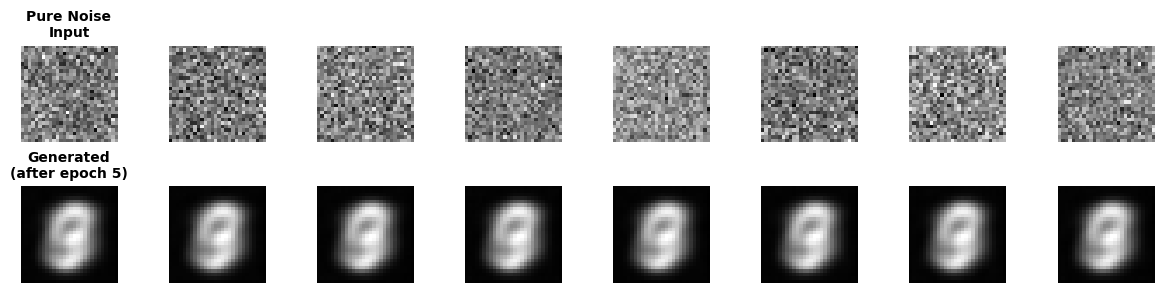


=== Sampling from Final Model (Epoch 5) ===


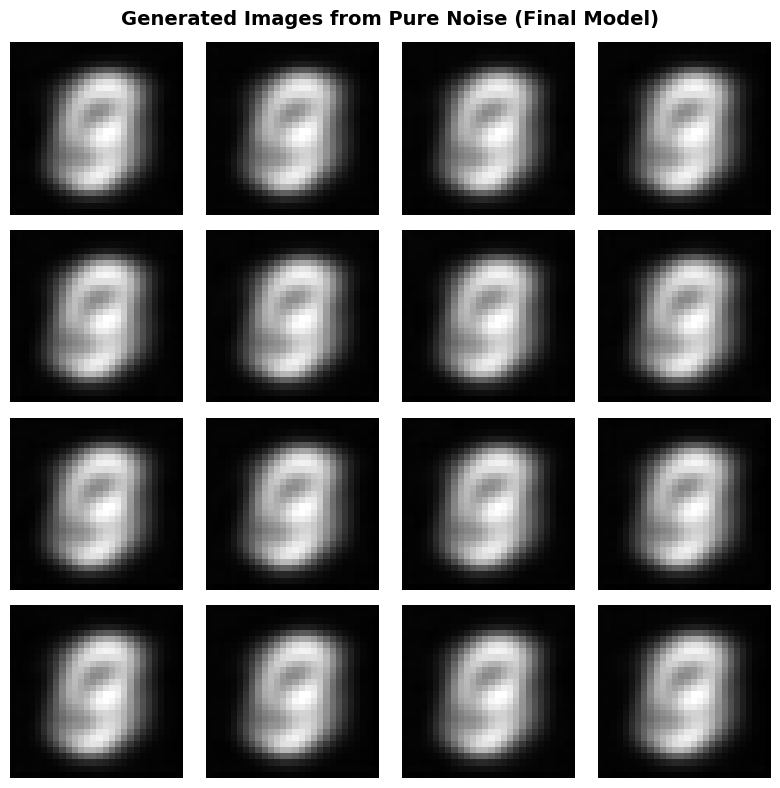


=== Observations ===
Observe the generated images above. What patterns do you see?
Do they resemble digits from the training set? Why might this be happening?


In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 64
learning_rate = 1e-3
hidden_dim = 64  # num_hiddens for UNet
num_epochs = 5  # Train for 5 epochs
# ===== end of code ====

# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
test_dataset = MNIST(root='./data', train=False, download=True, transform=ToTensor())

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()  # Mean Squared Error loss for denoising
# ===== end of code ====

# Store models at epoch 1 and 5 for visualization
model_epoch1 = None
model_epoch5 = None

# The training loops
train_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        
        # Input pure noise: x_0 ~ N(0, 1) - completely random noise, no image structure
        pure_noise = torch.randn_like(images)
        
        # Forward pass: model predicts image from pure noise
        outputs = model(pure_noise)
        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
    
    # Save model state after epoch 1 and 5
    if epoch == 0:  # After epoch 1 (0-indexed, so epoch 0 is after 1 epoch)
        model_epoch1 = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
        model_epoch1.load_state_dict(model.state_dict())
    elif epoch == 4:  # After epoch 5 (0-indexed, so epoch 4 is after 5 epochs)
        model_epoch5 = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
        model_epoch5.load_state_dict(model.state_dict())

# ===== end of code ====

# Visualize results after epoch 1
print("\n=== Results after Epoch 1 ===")
num_samples = 8
pure_noise_samples = torch.randn(num_samples, 1, 28, 28).to(device)

model_epoch1.eval()
with torch.no_grad():
    generated_epoch1 = model_epoch1(pure_noise_samples)

fig, axes = plt.subplots(2, num_samples, figsize=(12, 3))
for i in range(num_samples):
    axes[0, i].imshow(pure_noise_samples[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Pure Noise\nInput', fontsize=10, fontweight='bold')
    
    axes[1, i].imshow(generated_epoch1[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generated\n(after epoch 1)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Visualize results after epoch 5
print("\n=== Results after Epoch 5 ===")
model_epoch5.eval()
with torch.no_grad():
    generated_epoch5 = model_epoch5(pure_noise_samples)

fig, axes = plt.subplots(2, num_samples, figsize=(12, 3))
for i in range(num_samples):
    axes[0, i].imshow(pure_noise_samples[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Pure Noise\nInput', fontsize=10, fontweight='bold')
    
    axes[1, i].imshow(generated_epoch5[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generated\n(after epoch 5)', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Sample from the final trained model
print("\n=== Sampling from Final Model (Epoch 5) ===")
num_generations = 16
final_pure_noise = torch.randn(num_generations, 1, 28, 28).to(device)

model.eval()
with torch.no_grad():
    final_generated = model(final_pure_noise)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(num_generations):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(final_generated[i].cpu().squeeze(), cmap='gray')
    axes[row, col].axis('off')
plt.suptitle('Generated Images from Pure Noise (Final Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [23]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.l1 = nn.Linear(in_channels,out_channels)
        self.gelu = nn.GELU()
        self.l2 = nn.Linear(out_channels,out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        return self.l2(self.gelu(self.l1(x)))
        # ===== end of code ====
        


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        # Left path
        self.convblock1 = ConvBlock(in_channels, D)  # 28x28 -> 28x28, channels: in -> D
        self.downblock1 = DownBlock(D, D)       # 28x28 -> 14x14, channels: D -> D
        self.downblock2 = DownBlock(D, 2 * D)    # 14x14 -> 7x7, channels: D -> 2D
        
        # Middle to Final path
        self.flatten = Flatten()                 # 7x7 -> 1x1, 2D -> 2D
        self.upblock1 = UpBlock(4*D, D)       # 7x7 -> 14x14, channels: 4D -> D 
        self.upblock2 = UpBlock(2*D, D)           # 14x14 -> 28x28, channels: 2D -> D
        self.unflatten = Unflatten(2 * D)      # 1x1 -> 7x7, 2D -> 2D      
        self.convblock2 = ConvBlock(2 * D, D)   # 28x28 -> 28x28, channels: 2D -> D
        self.fcblock1 = FCBlock(1, 2*D)
        self.fcblock2 = FCBlock(1, D)
        
        # Output
        self.conv_final = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)# 28x28 -> 28x28, channels: 2D -> in_channels
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        
        #left path
        b1 = self.convblock1(x)# (D, 28, 28)
        b2 = self.downblock1(b1)   # (D, 14, 14)
        b3 = self.downblock2(b2) # (2D, 7, 7)
        b4 = self.flatten(b3)    # (2D, 1, 1)
        
        #middle to final path
        #add time to b5 and b7
        t_reshaped = t.unsqueeze(1)      # (N, 1)
        
        # Unflatten first, then condition with time embedding
        b5 = self.unflatten(b4)          # (N, 2*D, 7, 7)
        t_embed1 = self.fcblock1(t_reshaped)  # (N, 2*D)
        t_embed1 = t_embed1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*D) -> (N, 2*D, 1, 1)
        b5 = b5 * t_embed1               # Broadcast: (N, 2*D, 7, 7) * (N, 2*D, 1, 1)
        b6 = torch.cat([b3, b5], dim=1)      # (N, 4*D, 7, 7)
        b7 = self.upblock1(b6)               # (N, D, 14, 14)
        
        # Condition time embedding at upsampling stage
        t_embed2 = self.fcblock2(t_reshaped)  # (N, D)
        t_embed2 = t_embed2.unsqueeze(-1).unsqueeze(-1)  # (N, D) -> (N, D, 1, 1)
        b7 = b7 * t_embed2               # Broadcast: (N, D, 14, 14) * (N, D, 1, 1)
        
        b8 = torch.cat([b2, b7], dim=1)  # (N, 2*D, 14, 14)
        b9 = self.upblock2(b8)                       # (N, D, 28, 28)
        b10 = torch.cat([b1, b9], dim=1)            # (N, 2*D, 28, 28)
        b11 = self.convblock2(b10)                  # (N, D, 28, 28)
        return self.conv_final(b11)                 # (N, in_channels, 28, 28)
        # ===== end of code ====

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [24]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N, C, H, W = x_1.shape
    
    # Step 1: Sample random time t uniformly from [0, 1] for each sample
    t = torch.rand(N, device=x_1.device)  # (N,)
    
    # Step 2: Sample random noise x_0 ~ N(0, 1)
    x_0 = torch.randn_like(x_1)  # (N, C, H, W)
    
    # Step 3: Create interpolation x_t = (1 - t) * x_0 + t * x_1
    # Reshape t for broadcasting: (N,) -> (N, 1, 1, 1)
    t_broadcast = t.view(N, 1, 1, 1)
    x_t = (1 - t_broadcast) * x_0 + t_broadcast * x_1  # (N, C, H, W)
    
    # Step 4: Compute target velocity v_t = x_1 - x_0
    v_t = x_1 - x_0  # (N, C, H, W)
    
    # Step 5: Predict velocity using UNet
    v_pred = unet(x_t, t)  # (N, C, H, W)
    
    # Step 6: Compute MSE loss: ||v_pred - v_t||^2
    loss = torch.mean((v_pred - v_t) ** 2)
    
    return loss
    # ===== end of code ====

In [25]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    if seed is not None:
        torch.manual_seed(seed)
    
    H, W = img_wh
    # Get number of samples from unet (default to 1, but we'll need to infer from context)
    # For now, we'll generate 1 sample. If you need multiple, you can modify this.
    N = 1  # Number of samples to generate
    C = 1  # Assuming grayscale (MNIST), adjust if needed
    
    # Step 1: Initialize x_0 ~ N(0, 1) - pure noise
    x = torch.randn(N, C, H, W, device=next(unet.parameters()).device)
    
    # Step 2: Divide time from 0 to 1 into num_ts steps
    # Step 3: For each timestep, use Euler method to integrate
    dt = 1.0 / num_ts  # Time step size
    
    for i in range(num_ts):
        # Current time t
        t = torch.tensor([i / num_ts], device=x.device).expand(N)  # (N,)
        
        # Predict velocity using UNet
        v = unet(x, t)  # (N, C, H, W)
        
        # Euler step: x = x + dt * v
        x = x + dt * v
    
    return x
    # ===== end of code ====

In [26]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

Starting training on cuda...
Total batches per epoch: 938


Epoch 1/10: 100%|██████████| 938/938 [00:30<00:00, 30.33it/s]


Epoch 1/10 - Avg Loss: 0.177878 - LR: 0.007943
  -> Saved model checkpoint in memory at epoch 1


Epoch 2/10: 100%|██████████| 938/938 [00:30<00:00, 30.97it/s]


Epoch 2/10 - Avg Loss: 0.120404 - LR: 0.006310


...

Epoch 8/10 - Avg Loss: 0.094402 - LR: 0.001585


Epoch 9/10: 100%|██████████| 938/938 [00:30<00:00, 30.90it/s]


Epoch 9/10 - Avg Loss: 0.092815 - LR: 0.001259


Epoch 10/10: 100%|██████████| 938/938 [00:30<00:00, 30.68it/s]


Epoch 10/10 - Avg Loss: 0.092265 - LR: 0.001000
  -> Saved model checkpoint in memory at epoch 10
Training complete!


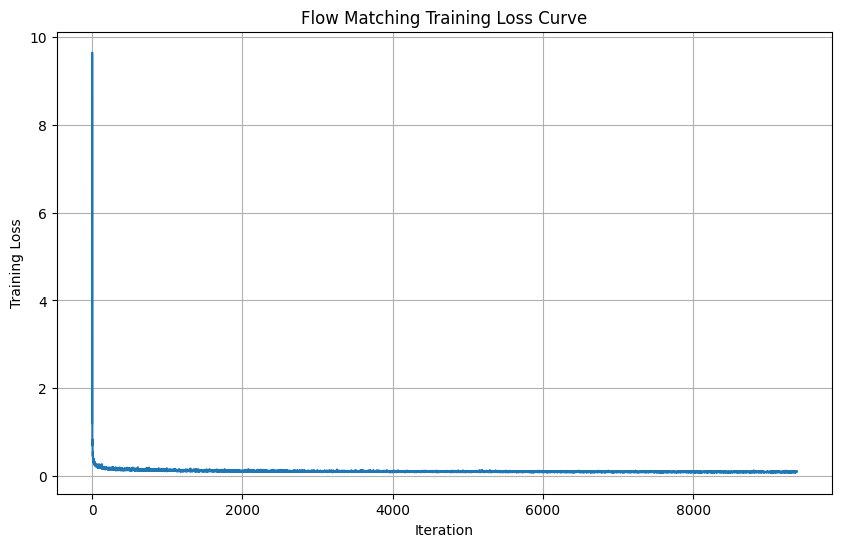

In [30]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
batch_size = 64
hidden_dim = 64
learning_rate = 1e-2
num_epochs = 10  # Adjust based on convergence
num_ts = 50  # Number of timesteps for flow matching

# Dataset and dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model: TimeConditionalUNet
# Note: num_classes is not used for unconditional flow matching, but required by architecture
model = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler: ExponentialLR with gamma=0.9
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1 ** (1.0/num_epochs))

# Training loop
train_losses = []
saved_models = {}  # Dictionary to store models at epochs 1, 5, and 10
print(f"Starting training on {device}...")
print(f"Total batches per epoch: {len(train_loader)}")

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []
    
    for batch_idx, (images, _) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        # Move images to device (clean images - no pre-noising)
        # Note: time_fm_forward handles noise sampling internally
        images = images.to(device)
        
        # Forward pass: compute loss using Algorithm 1
        loss = time_fm_forward(model, images, num_ts)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        train_losses.append(loss.item())
    
    # Update learning rate after each epoch
    scheduler.step()
    
    avg_loss = np.mean(epoch_losses)
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1}/{num_epochs} - Avg Loss: {avg_loss:.6f} - LR: {current_lr:.6f}")
    
    # Save model checkpoints in memory at epochs 1, 5, and 10
    if (epoch + 1) in [1, 5, 10]:
        # Create a copy of the model and save its state
        saved_model = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)
        saved_model.load_state_dict(model.state_dict())
        saved_models[epoch + 1] = saved_model
        print(f"  -> Saved model checkpoint in memory at epoch {epoch + 1}")

print("Training complete!")

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Flow Matching Training Loss Curve')
plt.grid(True)
plt.show()
# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet


Generating 16 samples from epoch 1...

Generating 16 samples from epoch 5...

Generating 16 samples from epoch 10...


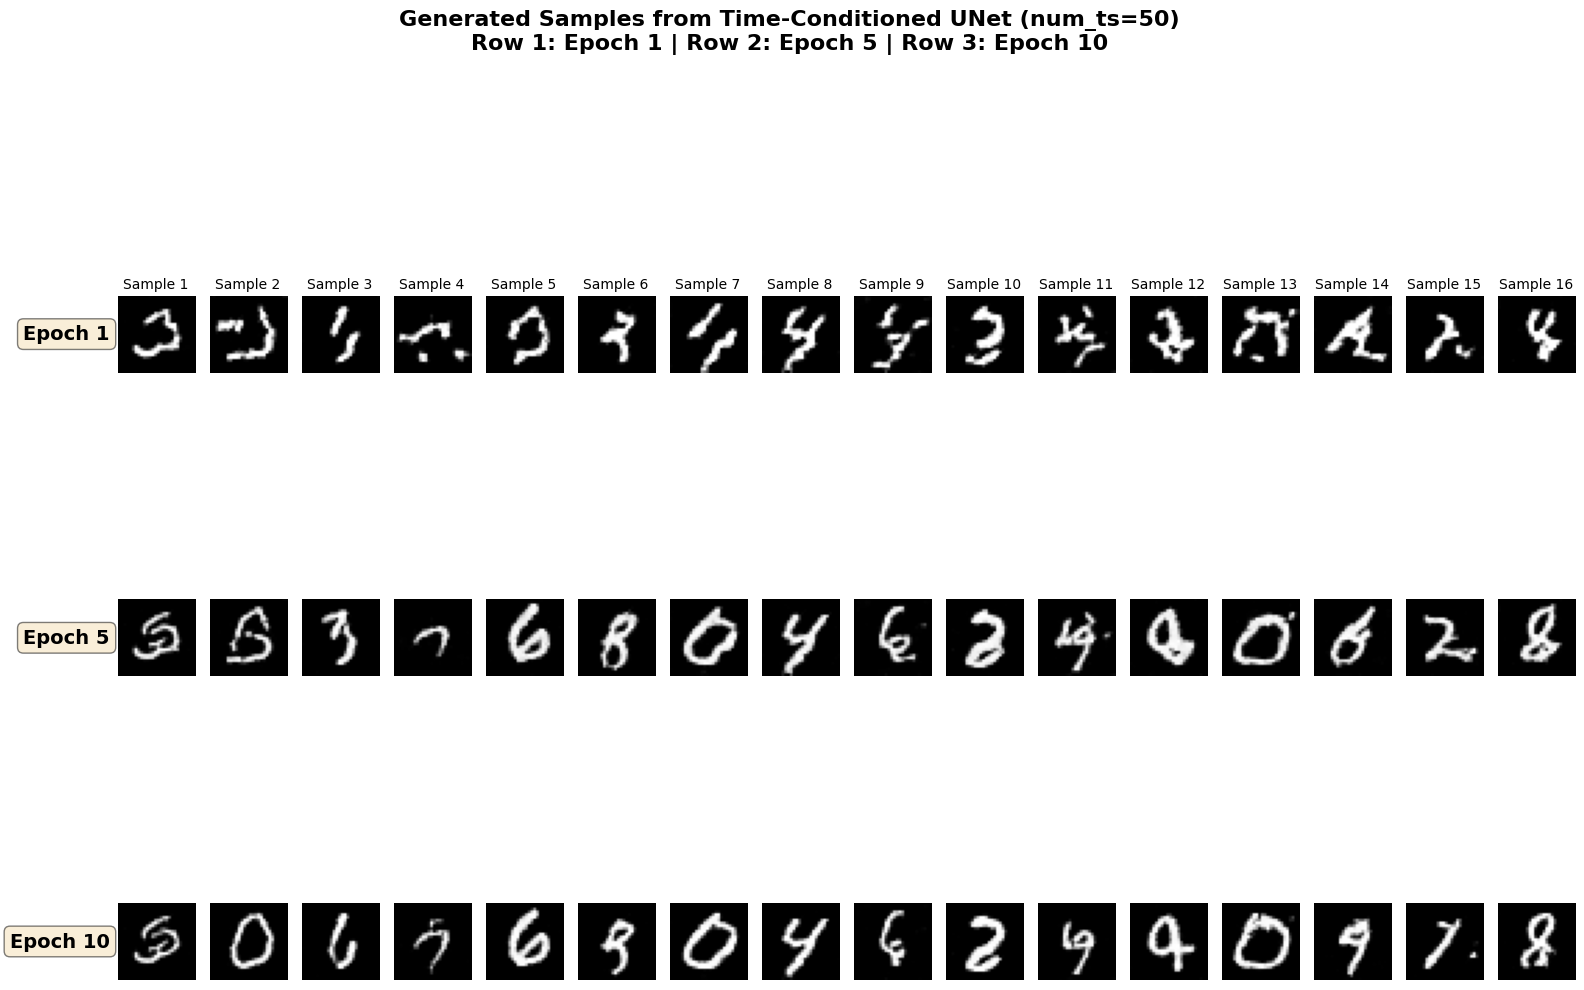


✓ Generated 16 samples from 3 checkpoint(s) successfully!
  - Epochs sampled: [1, 5, 10]


In [32]:
# Sampling from the UNet
# ===== your code here! ====
num_samples = 16  # Number of samples to generate
num_ts_sampling = 50  # Number of timesteps for sampling
checkpoint_epochs = [1, 5, 10]  # Epochs to sample from

# Generate samples from each saved model
all_samples = {}  # Dictionary to store samples from each epoch

for epoch_num in checkpoint_epochs:
    if epoch_num not in saved_models:
        print(f"Warning: Model from epoch {epoch_num} not found. Skipping.")
        continue
    
    print(f"\nGenerating {num_samples} samples from epoch {epoch_num}...")
    saved_model = saved_models[epoch_num]
    saved_model.eval()
    
    # Generate samples
    generated_samples = []
    
    for i in range(num_samples):
        sample = time_fm_sample(saved_model, img_wh=(28, 28), num_ts=num_ts_sampling, seed=i)
        generated_samples.append(sample)
    
    # Stack all samples: (num_samples, 1, 28, 28)
    generated_samples = torch.cat(generated_samples, dim=0)
    
    # Move to CPU and clamp to valid range [0, 1]
    generated_samples = generated_samples.cpu()
    generated_samples = torch.clamp(generated_samples, 0, 1)
    
    all_samples[epoch_num] = generated_samples

# Visualize samples from all epochs
if all_samples:
    num_epochs_to_show = len(all_samples)
    sorted_epochs = sorted(all_samples.keys())
    
    # Create figure with subplots
    fig, axes = plt.subplots(num_epochs_to_show, num_samples, figsize=(16, 4 * num_epochs_to_show))
    
    if num_epochs_to_show == 1:
        axes = axes.reshape(1, -1)
    
    # Plot samples for each epoch
    for row_idx, epoch_num in enumerate(sorted_epochs):
        samples = all_samples[epoch_num]
        for col_idx in range(num_samples):
            axes[row_idx, col_idx].imshow(samples[col_idx].squeeze(), cmap='gray')
            axes[row_idx, col_idx].axis('off')
        
        # Add clear label on the leftmost column
        axes[row_idx, 0].text(-0.1, 0.5, f'Epoch {epoch_num}', 
                               transform=axes[row_idx, 0].transAxes,
                               rotation=0, va='center', ha='right', 
                               fontsize=14, fontweight='bold',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Add column labels at the top
    for col_idx in range(num_samples):
        axes[0, col_idx].set_title(f'Sample {col_idx+1}', fontsize=10, pad=5)
    
    # Main title
    plt.suptitle(f'Generated Samples from Time-Conditioned UNet (num_ts={num_ts_sampling})\n' +
                 f'Row 1: Epoch {sorted_epochs[0]} | Row 2: Epoch {sorted_epochs[1] if len(sorted_epochs) > 1 else "N/A"} | Row 3: Epoch {sorted_epochs[2] if len(sorted_epochs) > 2 else "N/A"}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.subplots_adjust(left=0.08, top=0.93)  # Add space for labels
    plt.show()
    
    print(f"\n✓ Generated {num_samples} samples from {len(all_samples)} checkpoint(s) successfully!")
    print(f"  - Epochs sampled: {sorted_epochs}")
else:
    print("❌ No saved models found. Please run the training cell first to generate saved_models.")
# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [33]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        # Left path
        self.convblock1 = ConvBlock(in_channels, D)  # 28x28 -> 28x28, channels: in -> D
        self.downblock1 = DownBlock(D, D)       # 28x28 -> 14x14, channels: D -> D
        self.downblock2 = DownBlock(D, 2 * D)    # 14x14 -> 7x7, channels: D -> 2D
        
        # Middle to Final path
        self.flatten = Flatten()                 # 7x7 -> 1x1, 2D -> 2D
        self.upblock1 = UpBlock(4*D, D)       # 7x7 -> 14x14, channels: 4D -> D 
        self.upblock2 = UpBlock(2*D, D)           # 14x14 -> 28x28, channels: 2D -> D
        self.unflatten = Unflatten(2 * D)      # 1x1 -> 7x7, 2D -> 2D      
        self.convblock2 = ConvBlock(2 * D, D)   # 28x28 -> 28x28, channels: 2D -> D
        self.fcblock1_t = FCBlock(1, 2*D)
        self.fcblock1_c = FCBlock(num_classes, 2*D)  # Fixed: input is one-hot encoded (num_classes dims)
        self.fcblock2_t = FCBlock(1, D)
        self.fcblock2_c = FCBlock(num_classes, D)  # Fixed: input is one-hot encoded (num_classes dims)
        
        # Store num_classes for mask handling
        self.num_classes = num_classes
        
        # Output
        self.conv_final = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)# 28x28 -> 28x28, channels: 2D -> in_channels
        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        #left path
        b1 = self.convblock1(x)# (D, 28, 28)
        b2 = self.downblock1(b1)   # (D, 14, 14)
        b3 = self.downblock2(b2) # (2D, 7, 7)
        b4 = self.flatten(b3)    # (2D, 1, 1)
        
        #middle to final path
        #add time and class conditioning to b5 and b7
        t_reshaped = t.unsqueeze(1)      # (N, 1)
        c_ohe = torch.nn.functional.one_hot(c, num_classes=self.num_classes).float()  # (N, num_classes)
        
        # Unflatten first, then condition with time and class embeddings
        b5 = self.unflatten(b4)          # (N, 2*D, 7, 7)
        t_embed1 = self.fcblock1_t(t_reshaped)  # (N, 2*D)
        t_embed1 = t_embed1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*D) -> (N, 2*D, 1, 1)
        c_embed1 = self.fcblock1_c(c_ohe) #(N, 2*D)
        c_embed1 = c_embed1.unsqueeze(-1).unsqueeze(-1)  # (N, 2*D) -> (N, 2*D, 1, 1)
        
        # Handle mask: when mask == 0, use identity (1) for multiplicative conditioning (unconditional)
        if mask is not None:
            mask_embed1 = mask.unsqueeze(1).unsqueeze(-1).unsqueeze(-1).float()  # (N, 1, 1, 1)
            # When mask == 1: use learned embedding, when mask == 0: use identity (1)
            c_embed1 = mask_embed1 * c_embed1 + (1 - mask_embed1) * torch.ones_like(c_embed1)
        
        # Combine: multiplicative class conditioning + additive time conditioning
        b5 = b5 * c_embed1 + t_embed1  # (N, 2*D, 7, 7)
        b6 = torch.cat([b3, b5], dim=1)      # (N, 4*D, 7, 7)
        b7 = self.upblock1(b6)               # (N, D, 14, 14)
        
        # Condition time and class embeddings at upsampling stage
        t_embed2 = self.fcblock2_t(t_reshaped)  # (N, D)
        t_embed2 = t_embed2.unsqueeze(-1).unsqueeze(-1)  # (N, D) -> (N, D, 1, 1)
        c_embed2 = self.fcblock2_c(c_ohe)  # (N, D)
        c_embed2 = c_embed2.unsqueeze(-1).unsqueeze(-1)  # (N, D) -> (N, D, 1, 1)
        
        # Handle mask: when mask == 0, use identity (1) for multiplicative conditioning (unconditional)
        if mask is not None:
            mask_embed2 = mask.unsqueeze(1).unsqueeze(-1).unsqueeze(-1).float()  # (N, 1, 1, 1)
            # When mask == 1: use learned embedding, when mask == 0: use identity (1)
            c_embed2 = mask_embed2 * c_embed2 + (1 - mask_embed2) * torch.ones_like(c_embed2)
        
        # Combine: multiplicative class conditioning + additive time conditioning
        b7 = b7 * c_embed2 + t_embed2  # (N, D, 14, 14)
        
        b8 = torch.cat([b2, b7], dim=1)  # (N, 2*D, 14, 14)
        b9 = self.upblock2(b8)                       # (N, D, 28, 28)
        b10 = torch.cat([b1, b9], dim=1)            # (N, 2*D, 28, 28)
        b11 = self.convblock2(b10)                  # (N, D, 28, 28)
        return self.conv_final(b11)                 # (N, in_channels, 28, 28)
        # ===== end of code ====

In [34]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps (not used in training).

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    N, C, H, W = x_1.shape
    device = x_1.device
    
    # Step 3 & 4: Make c into one-hot vector, then with probability p_uncond set c to zero-vector
    # Create mask: 1 means keep conditioning, 0 means drop conditioning
    mask = (torch.rand(N, device=device) > p_uncond).float()  # (N,)
    
    # Step 5: Sample random time t uniformly from [0, 1]
    t = torch.rand(N, device=device)  # (N,)
    
    # Step 6: Sample random noise x_0 ~ N(0, I)
    x_0 = torch.randn_like(x_1)  # (N, C, H, W)
    
    # Step 7: Create interpolation x_t = (1 - t) * x_0 + t * x_1
    t_broadcast = t.view(N, 1, 1, 1)  # (N, 1, 1, 1) for broadcasting
    x_t = (1 - t_broadcast) * x_0 + t_broadcast * x_1  # (N, C, H, W)
    
    # Step 8: Compute target velocity v_t = x_1 - x_0
    v_t = x_1 - x_0  # (N, C, H, W)
    
    # Predict velocity using class-conditional UNet
    # The mask is applied inside the UNet's forward pass
    v_pred = unet(x_t, c, t, mask=mask)  # (N, C, H, W)
    
    # Compute MSE loss: ||v_pred - v_t||^2
    loss = torch.mean((v_pred - v_t) ** 2)
    
    return loss
    # ===== end of code ====

In [37]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    if seed is not None:
        torch.manual_seed(seed)
    
    H, W = img_wh
    device = next(unet.parameters()).device
    N = c.shape[0]  # Number of samples (infer from condition tensor)
    C = 1  # MNIST grayscale
    
    # Move condition to device
    c = c.to(device)
    
    # Step 1: Initialize x_0 ~ N(0, 1) - pure noise
    x = torch.randn(N, C, H, W, device=device)
    
    # Step 2 & 3: Euler integration from t=0 to t=1 with classifier-free guidance
    dt = 1.0 / num_ts  # Time step size
    
    for i in range(num_ts):
        # Current time t (normalized to [0, 1])
        t = torch.full((N,), i * dt, device=device)  # (N,)
        
        # Predict conditional velocity: u_θ(x_t, t, c)
        # mask=None means no dropout - use full conditioning
        v_cond = unet(x, c, t, mask=None)  # (N, C, H, W)
        
        # Predict unconditional velocity: u_θ(x_t, t, 0)
        # Create zero mask to drop all conditioning
        mask_uncond = torch.zeros(N, device=device)  # All zeros = drop conditioning
        v_uncond = unet(x, c, t, mask=mask_uncond)  # (N, C, H, W)
        
        # Classifier-free guidance: v = v_uncond + γ * (v_cond - v_uncond)
        # This is equivalent to: v = (1 - γ) * v_uncond + γ * v_cond
        v = v_uncond + guidance_scale * (v_cond - v_uncond)  # (N, C, H, W)
        
        # Euler step: x_{t+dt} = x_t + dt * v_t
        x = x + dt * v
    
    # Clamp to [0, 1] for visualization
    x = torch.clamp(x, 0, 1)
    
    return x
    # ===== end of code ====

In [35]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

Starting class-conditional training on cuda...
Total batches per epoch: 938
Unconditional probability (p_uncond): 0.1


Epoch 1/10: 100%|██████████| 938/938 [00:33<00:00, 27.89it/s]


Epoch 1/10 - Avg Loss: 0.198292 - LR: 0.007943
  -> Saved model checkpoint in memory at epoch 1


Epoch 2/10: 100%|██████████| 938/938 [00:33<00:00, 28.36it/s]


Epoch 2/10 - Avg Loss: 0.118896 - LR: 0.006310


...

Epoch 8/10 - Avg Loss: 0.088847 - LR: 0.001585


Epoch 9/10: 100%|██████████| 938/938 [00:40<00:00, 22.92it/s]


Epoch 9/10 - Avg Loss: 0.087010 - LR: 0.001259


Epoch 10/10: 100%|██████████| 938/938 [00:35<00:00, 26.58it/s]


Epoch 10/10 - Avg Loss: 0.085687 - LR: 0.001000
  -> Saved model checkpoint in memory at epoch 10
Training complete!


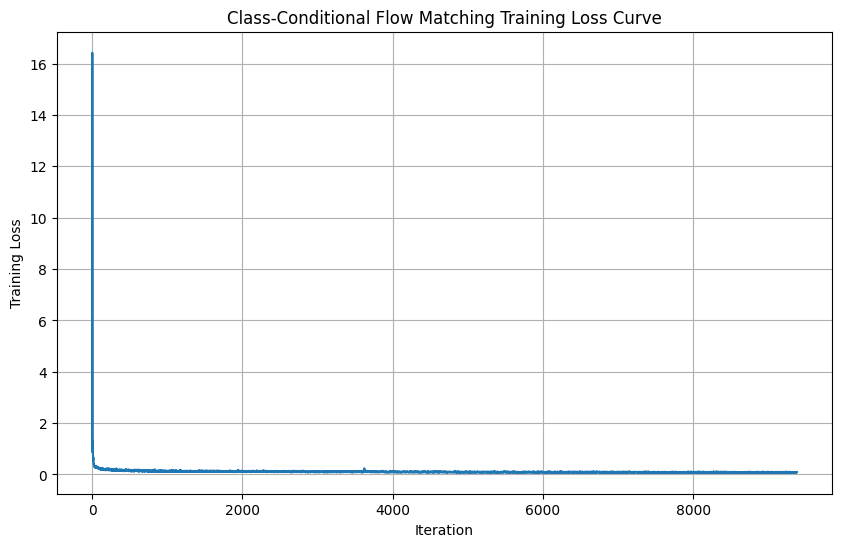

In [36]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
batch_size = 64
hidden_dim = 64
learning_rate = 1e-2
num_epochs = 10  # Class-conditioned trains faster, so 10 epochs is good
num_ts = 50  # Number of timesteps for sampling (not used in training)
p_uncond = 0.1  # Probability of unconditioning (10% dropout for classifier-free guidance)

# Dataset and dataloader
train_dataset = MNIST(root='./data', train=True, download=True, transform=ToTensor())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model: ClassConditionalUNet (CHANGED from TimeConditionalUNet)
model = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler: ExponentialLR with gamma=0.1^(1.0/num_epochs)
gamma = 0.1 ** (1.0 / num_epochs)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

# Training loop
train_losses = []
saved_models = {}  # Dictionary to store models at epochs 1, 5, and 10
print(f"Starting class-conditional training on {device}...")
print(f"Total batches per epoch: {len(train_loader)}")
print(f"Unconditional probability (p_uncond): {p_uncond}")

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []
    
    for batch_idx, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)  # CHANGED: Now we use labels!
        
        # Forward pass: compute loss using Algorithm B.3
        loss = class_fm_forward(model, images, labels, p_uncond, num_ts)  # CHANGED function
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        train_losses.append(loss.item())
    
    # Update learning rate after each epoch
    scheduler.step()
    
    avg_loss = np.mean(epoch_losses)
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1}/{num_epochs} - Avg Loss: {avg_loss:.6f} - LR: {current_lr:.6f}")
    
    # Save model checkpoints in memory at epochs 1, 5, and 10
    if (epoch + 1) in [1, 5, 10]:
        # Create a copy of the model and save its state
        saved_model = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)  # CHANGED
        saved_model.load_state_dict(model.state_dict())
        saved_models[epoch + 1] = saved_model
        print(f"  -> Saved model checkpoint in memory at epoch {epoch + 1}")

print("Training complete!")

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.xlabel('Iteration')
plt.ylabel('Training Loss')
plt.title('Class-Conditional Flow Matching Training Loss Curve')
plt.grid(True)
plt.show()

# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

Generating samples with classifier-free guidance (γ=5.0)...


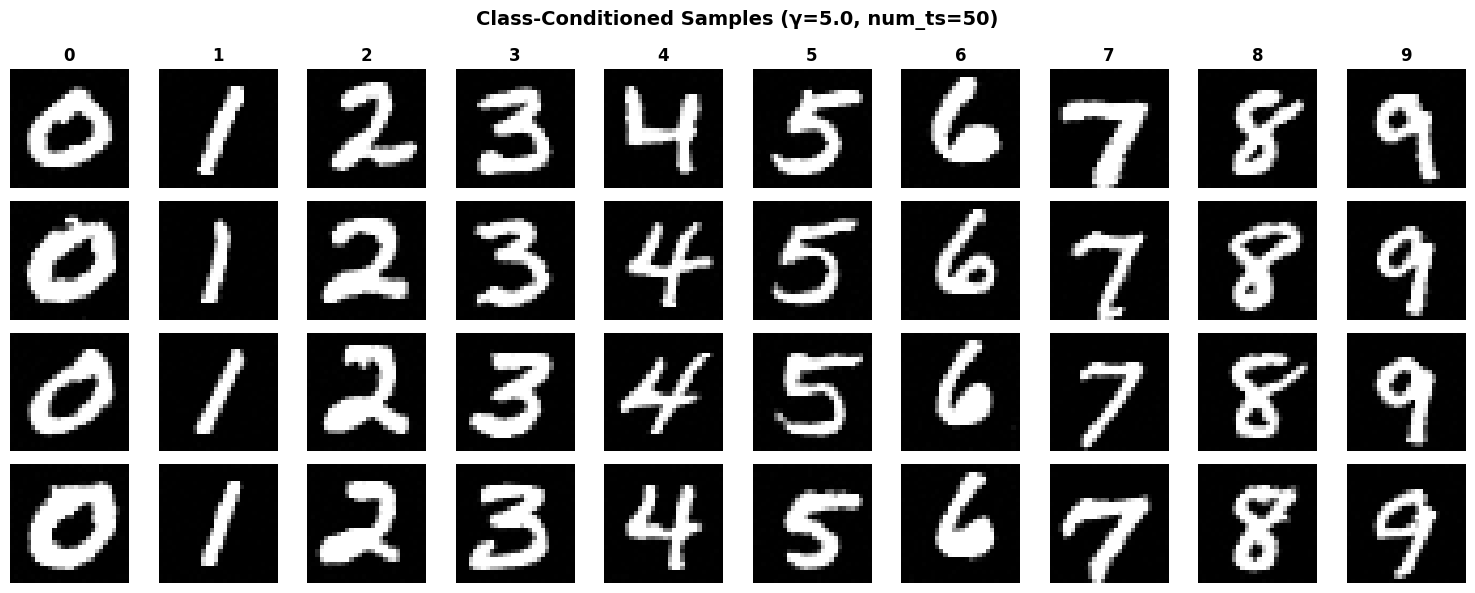


Generated 4 instances of each digit (0-9) = 40 samples total!

Generating samples from checkpointed models...


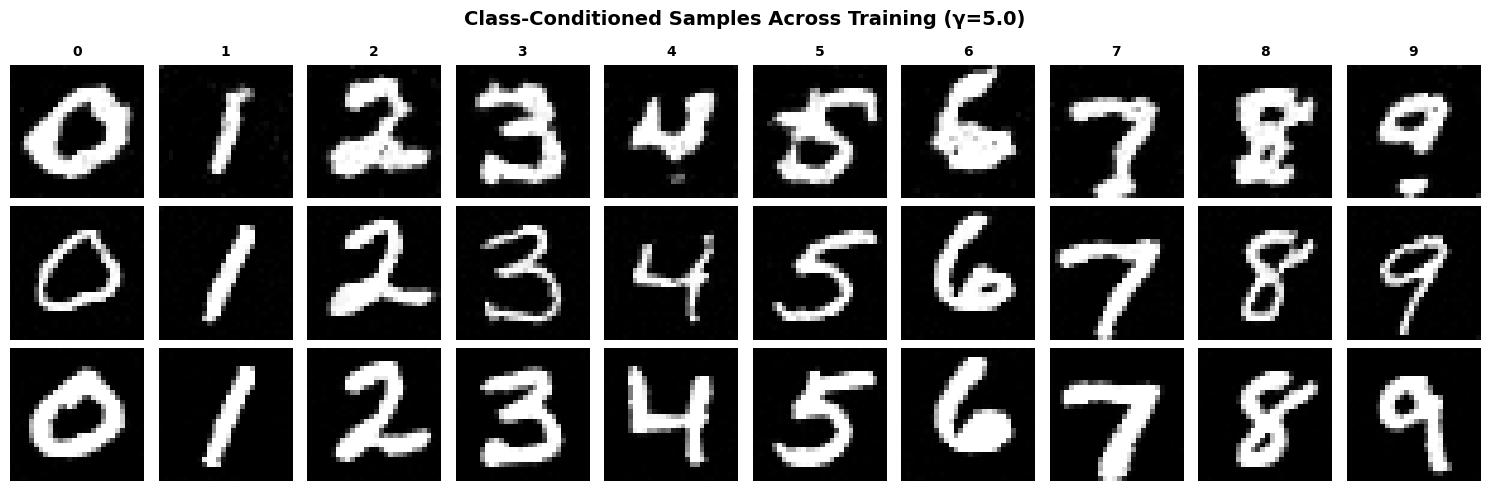

Sampling complete!


In [38]:
# Sampling from the UNet
# ===== your code here! ====
model.eval()

num_ts_sampling = 50  # Number of timesteps for sampling
guidance_scale = 5.0  # CFG scale as specified in the spec

# Generate 4 instances of each digit (0-9) as shown in the spec
print(f"Generating samples with classifier-free guidance (γ={guidance_scale})...")

# Create condition tensor: 4 samples for each digit 0-9
digits = list(range(10))  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
c = torch.tensor(digits * 4)  # Repeat each digit 4 times: 40 samples total

# Generate samples
generated_samples = class_fm_sample(
    model,
    c=c,
    img_wh=(28, 28),
    num_ts=num_ts_sampling,
    guidance_scale=guidance_scale,
    seed=0
)

# Move to CPU for visualization
generated_samples = generated_samples.cpu()

# Visualize in a grid: 10 columns (one per digit) x 4 rows (4 instances each)
fig, axes = plt.subplots(4, 10, figsize=(15, 6))

for i in range(40):
    row = i // 10  # Which instance (0-3)
    col = i % 10   # Which digit (0-9)
    
    axes[row, col].imshow(generated_samples[i].squeeze(), cmap='gray')
    axes[row, col].axis('off')
    
    # Add digit label on top row
    if row == 0:
        axes[row, col].set_title(f'{col}', fontsize=12, fontweight='bold')

plt.suptitle(f'Class-Conditioned Samples (γ={guidance_scale}, num_ts={num_ts_sampling})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nGenerated 4 instances of each digit (0-9) = 40 samples total!")

# Optional: Also visualize samples from saved checkpoints at epochs 1, 5, and 10
print("\nGenerating samples from checkpointed models...")

fig, axes = plt.subplots(3, 10, figsize=(15, 5))
epochs_to_show = [1, 5, 10]

for epoch_idx, epoch in enumerate(epochs_to_show):
    if epoch in saved_models:
        checkpoint_model = saved_models[epoch]
        checkpoint_model.eval()
        
        # Generate one sample per digit (0-9) for this epoch
        c_checkpoint = torch.tensor(list(range(10)))
        samples = class_fm_sample(
            checkpoint_model,
            c=c_checkpoint,
            img_wh=(28, 28),
            num_ts=num_ts_sampling,
            guidance_scale=guidance_scale,
            seed=0
        )
        samples = samples.cpu()
        
        # Display
        for digit in range(10):
            axes[epoch_idx, digit].imshow(samples[digit].squeeze(), cmap='gray')
            axes[epoch_idx, digit].axis('off')
            
            # Add digit label on top row
            if epoch_idx == 0:
                axes[epoch_idx, digit].set_title(f'{digit}', fontsize=10, fontweight='bold')
        
        # Add epoch label on left
        axes[epoch_idx, 0].set_ylabel(f'Epoch {epoch}', fontsize=12, fontweight='bold', rotation=0, labelpad=40)

plt.suptitle(f'Class-Conditioned Samples Across Training (γ={guidance_scale})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Sampling complete!")
# ===== end of code ====